# Model Training - Blast Damage Classification

Predicting `damage_category` from blast parameters + structure type. Comparing Random Forest, XGBoost, and a small MLP. Using stratified splits and per-class F1 given the imbalance seen in the EDA notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import xgboost as xgb

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../data/blast_damage_dataset.csv")
df.head()

,charge_weight_kg,explosive_type,charge_shape,tnt_equivalent_weight_kg,standoff_distance_m,scaled_distance_Z,structure_type,quality_factor,peak_overpressure_kpa,impulse_kpa_ms,damage_category
0,306.765,RDX,cylindrical,638.072,10.230,1.1883,glazing_window,0.766,869.742,104.555,collapse
1,339.173,C4,cylindrical,604.066,1.971,0.2332,masonry_wall,1.106,14136.392,500.297,collapse
2,459.840,RDX,spherical,735.744,10.479,1.1607,glazing_window,0.885,1085.875,110.513,collapse
3,268.935,C4,spherical,368.441,6.543,0.9127,steel_frame,0.981,1530.401,107.571,collapse
4,23.995,C4,spherical,32.874,1.261,0.3937,rc_wall,1.257,6348.143,107.264,moderate


## 1. Feature engineering

In [2]:
damage_order = ["none", "minor", "moderate", "severe", "collapse"]

df_model = df.copy()

# Log-transform right-skewed numeric features (per EDA notebook findings)
for col in ["charge_weight_kg", "standoff_distance_m", "peak_overpressure_kpa", "impulse_kpa_ms"]:
    df_model[f"log_{col}"] = np.log1p(df_model[col])

# One-hot encode structure_type
df_model = pd.get_dummies(df_model, columns=["structure_type"], prefix="struct")

feature_cols = [
    "log_charge_weight_kg", "log_standoff_distance_m", "scaled_distance_Z",
    "log_peak_overpressure_kpa", "log_impulse_kpa_ms", "quality_factor",
] + [c for c in df_model.columns if c.startswith("struct_")]

X = df_model[feature_cols]

label_encoder = LabelEncoder()
label_encoder.fit(damage_order)  # fix class order explicitly
y = label_encoder.transform(df_model["damage_category"])

feature_cols

['log_charge_weight_kg',
 'log_standoff_distance_m',
 'scaled_distance_Z',
 'log_peak_overpressure_kpa',
 'log_impulse_kpa_ms',
 'quality_factor',
 'struct_glazing_window',
 'struct_masonry_wall',
 'struct_rc_wall',
 'struct_steel_frame']

## 2. Train/test split (stratified)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
pd.Series(y_train).value_counts().sort_index()

Train shape: (6400, 10)  Test shape: (1600, 10)


0    1756
1     579
2     434
3    3229
4     402
Name: count, dtype: int64

## 3. Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
print("Random Forest accuracy:", accuracy_score(y_test, rf_preds))
print("Random Forest macro-F1:", f1_score(y_test, rf_preds, average="macro"))
print()
print(classification_report(y_test, rf_preds, target_names=damage_order))

Random Forest accuracy: 0.95
Random Forest macro-F1: 0.8874727953887864

              precision    recall  f1-score   support

        none       0.99      0.98      0.98       439
       minor       0.83      0.87      0.85       145
    moderate       0.81      0.78      0.79       109
      severe       0.99      0.99      0.99       807
    collapse       0.81      0.83      0.82       100

    accuracy                           0.95      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.95      0.95      0.95      1600



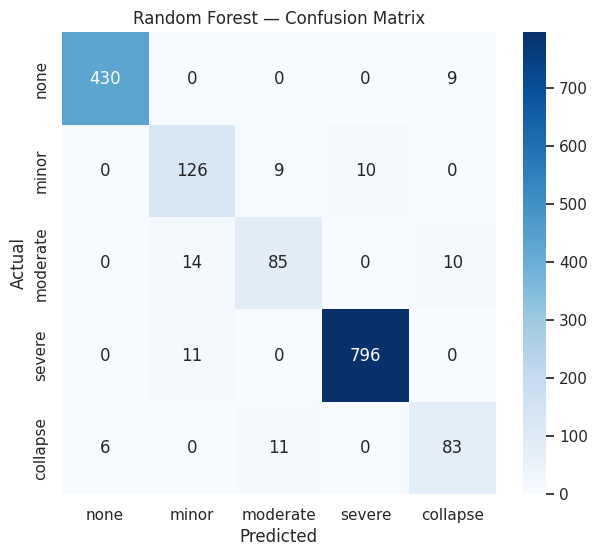

In [5]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=damage_order, yticklabels=damage_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")
plt.show()

/tmp/ipykernel_600/55077076.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="rocket")


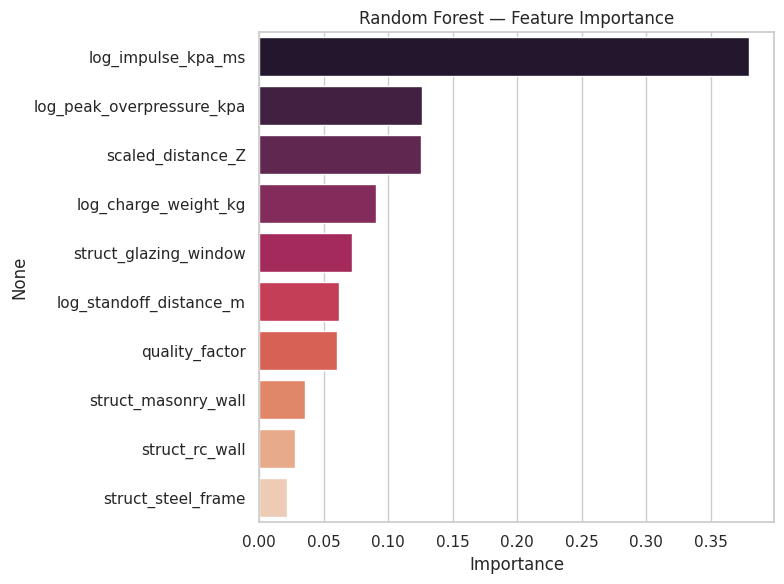

In [6]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="rocket")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Sanity check: `scaled_distance_Z` and the log overpressure/impulse features should dominate feature importance since they're the direct physical drivers here.

## 4. XGBoost

In [7]:
# Compute sample weights to address class imbalance (XGBoost has no
# built-in class_weight="balanced" for multiclass, so we do it manually)
class_counts = pd.Series(y_train).value_counts()
class_weights = {cls: len(y_train) / (len(class_counts) * count)
                 for cls, count in class_counts.items()}
sample_weights = np.array([class_weights[label] for label in y_train])

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=len(damage_order),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

xgb_preds = xgb_model.predict(X_test)
print("XGBoost accuracy:", accuracy_score(y_test, xgb_preds))
print("XGBoost macro-F1:", f1_score(y_test, xgb_preds, average="macro"))
print()
print(classification_report(y_test, xgb_preds, target_names=damage_order))

XGBoost accuracy: 0.971875
XGBoost macro-F1: 0.9403504994782284

              precision    recall  f1-score   support

        none       0.99      0.99      0.99       439
       minor       0.88      0.92      0.90       145
    moderate       0.87      0.93      0.90       109
      severe       1.00      0.98      0.99       807
    collapse       0.92      0.92      0.92       100

    accuracy                           0.97      1600
   macro avg       0.93      0.95      0.94      1600
weighted avg       0.97      0.97      0.97      1600



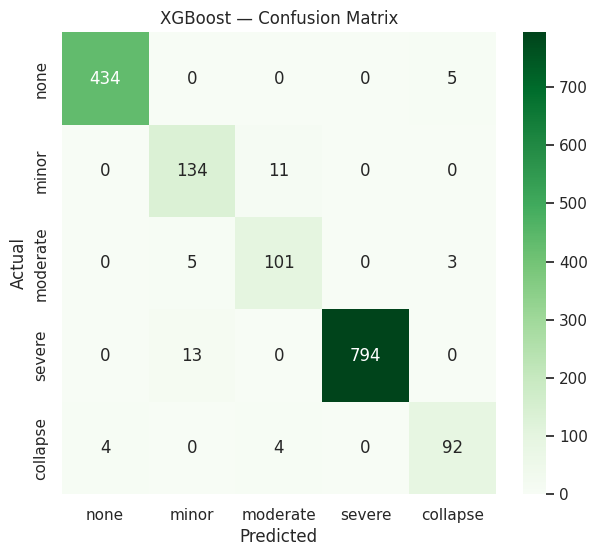

In [8]:
cm_xgb = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=damage_order, yticklabels=damage_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost — Confusion Matrix")
plt.show()

## 5. Small Neural Net (MLPClassifier)

Scaling inputs since NNs need it. This is a quick sklearn MLP for comparison - would port to PyTorch for a more serious version later.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
mlp.fit(X_train_scaled, y_train)

mlp_preds = mlp.predict(X_test_scaled)
print("MLP accuracy:", accuracy_score(y_test, mlp_preds))
print("MLP macro-F1:", f1_score(y_test, mlp_preds, average="macro"))
print()
print(classification_report(y_test, mlp_preds, target_names=damage_order))

MLP accuracy: 0.9875
MLP macro-F1: 0.9735663377329242

              precision    recall  f1-score   support

        none       0.99      1.00      0.99       439
       minor       0.97      0.95      0.96       145
    moderate       0.95      0.96      0.96       109
      severe       1.00      1.00      1.00       807
    collapse       0.96      0.96      0.96       100

    accuracy                           0.99      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.99      0.99      0.99      1600



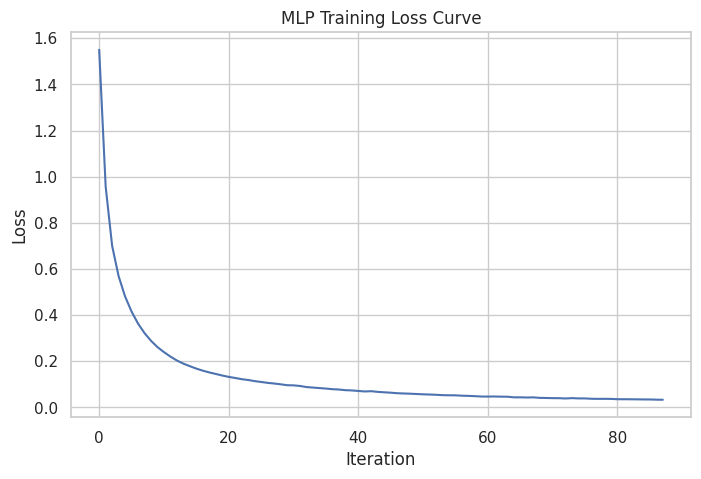

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## 6. Model comparison

In [11]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "MLP (sklearn)"],
    "Accuracy": [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, mlp_preds),
    ],
    "Macro F1": [
        f1_score(y_test, rf_preds, average="macro"),
        f1_score(y_test, xgb_preds, average="macro"),
        f1_score(y_test, mlp_preds, average="macro"),
    ],
})
results

,Model,Accuracy,Macro F1
0,Random Forest,0.950000,0.887473
1,XGBoost,0.971875,0.940350
2,MLP (sklearn),0.987500,0.973566


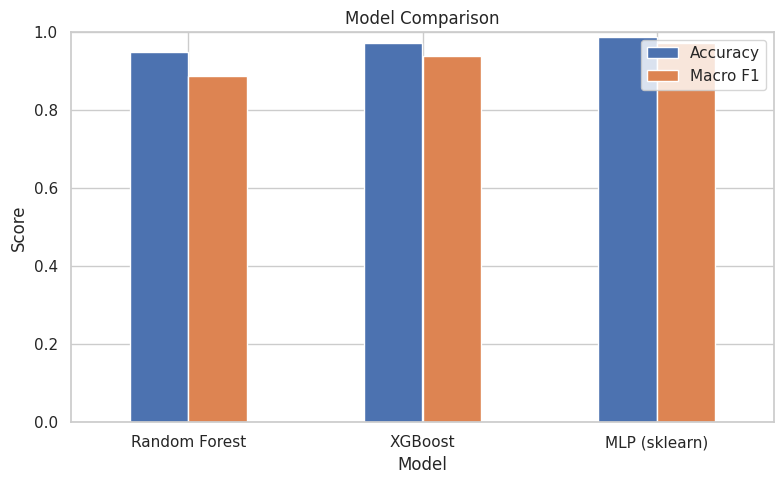

In [12]:
results.set_index("Model")[["Accuracy", "Macro F1"]].plot(kind="bar", figsize=(8, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Notes & next steps

- Macro F1 is the fairer metric here, not accuracy, since `none`/`severe` dominate the classes
- RF and XGBoost beating the MLP would be normal on tabular data this size - not a red flag
- Next: try SMOTE for the minority classes, port MLP to PyTorch, validate against real blast-test data if I can find any, wrap in a small API/app